In [429]:
#Librerias
import csv
import matplotlib.pyplot as plt
import numpy as np
import os

In [430]:
#carga_de_datos
def cargar_datos_csv_listas(ruta_archivo):
    FSC_A = [] ;     SSC_A = [] ;    FL1_A = [] ;    FL2_A = [];     FL3_A = [] ;     FL4_A = []
    FSC_H = [];    SSC_H = [];    FL1_H = [];    FL2_H = [];    FL3_H = [];    FL4_H = []
    
    Width = [];    Time = []
    
    with open(ruta_archivo, newline='') as archivo:  #
        lector = csv.reader(archivo)
        next(lector)  
        
        for fila in lector:
            FSC_A.append(int(fila[0]))
            SSC_A.append(int(fila[1]))
            FL1_A.append(int(fila[2]))
            FL2_A.append(int(fila[3]))
            FL3_A.append(int(fila[4]))
            FL4_A.append(int(fila[5]))
            FSC_H.append(int(fila[6]))
            SSC_H.append(int(fila[7]))
            FL1_H.append(int(fila[8]))
            FL2_H.append(int(fila[9]))
            FL3_H.append(int(fila[10]))
            FL4_H.append(int(fila[11]))
            Width.append(int(fila[12]))
            Time.append(int(fila[13]))
    
    return (FSC_A, SSC_A, FL1_A, FL2_A, FL3_A, FL4_A,
            FSC_H, SSC_H, FL1_H, FL2_H, FL3_H, FL4_H,
            Width, Time)

In [431]:
colores = {
    'glucosa': '#480058',
    'glicerol_etanol': '#4B75FF',
    'glicerol': '#FFA213',
    'glucosa_etanol': '#B72818',
    'cepaSB10_LB': '#480058',
    'cepaSB10_LBE': '#4B75FF',
    'cepapMS201_LB': '#FFA213',
    'cepapMS201_LBE': '#B72818'
}

estilos = {
    'glucosa': '-.',
    'glicerol_etanol': ':',
    'glicerol': '-',
    'glucosa_etanol': '--',
    'cepaSB10_LB': '-.',
    'cepaSB10_LBE': ':',
    'cepa3_LB': '-',
    'cepa4_LB': '--'
}

In [432]:
def grafica_scatter(datos_dict, nombre_base):
    """
    Genera y guarda la gráfica scatter (2x2).
    """
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()

    save_path_scatter = os.path.join(script_dir, f"{nombre_base}_scatter.png")

    # 1. Creamos la figura y los ejes PRIMERO
    fig, axes = plt.subplots(2, 2, figsize=(20, 15))
    
    # 2. Ponemos el título general de la figura (supratítulo)
    fig.suptitle("Medidas de Tamaño vs Granularidad", fontsize=35, fontweight='bold', y=0.98)
    
    axes = axes.flatten()

    for i, (nombre, datos) in enumerate(datos_dict.items()):
        FL1_A, FSC_H, SSC_H = datos
        ax = axes[i]

        mask = (np.array(FSC_H) > 0) & (np.array(SSC_H) > 0)
        fsc_filtered = np.array(FSC_H)[mask]
        ssc_filtered = np.array(SSC_H)[mask]

        ax.scatter(
            fsc_filtered,
            ssc_filtered,
            s=15,
            alpha=0.5,
            c=colores.get(nombre, 'blue'),
            marker='.'
        )

        ax.set_xscale('log')
        ax.set_yscale('log')

        nombre_bonito = nombre.replace("_", " ").title()

        ax.set_title(nombre_bonito + f" ({len(fsc_filtered)} puntos)", fontsize=30, fontweight='bold', pad=15)
        ax.set_xlabel('FSC-H (Tamaño celular)', fontsize=30, labelpad=15)
        ax.set_ylabel('SSC-H (Granularidad)', fontsize=30, labelpad=15)
        
        ax.tick_params(axis='both', which='major', labelsize=30)
        ax.grid(True, alpha=0.2, which='both')

    # 3. Ajustes de espaciado FUERA del bucle
    plt.subplots_adjust(
        hspace=0.4, 
        wspace=0.3,
        top=0.5,    
        bottom=0.1
    )
        
    plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Ajusta el layout para no tapar el suptitle
    fig.savefig(save_path_scatter, dpi=300, bbox_inches='tight')

    print(f"Scatter guardado: {save_path_scatter}")

    return fig

In [433]:
def grafica_histograma(datos_dict, nombre_base):
    try:
        script_dir = os.path.dirname(os.path.abspath(__file__))
    except NameError:
        script_dir = os.getcwd()

    save_path_hist = os.path.join(script_dir, f"{nombre_base}_histogram.png")
    
    fig, ax_main = plt.subplots(figsize=(20, 15))
    
    # 1. Ajustar márgenes para dar espacio al título y etiquetas grandes
    plt.subplots_adjust(top=0.90, bottom=0.15, left=0.15, right=0.95)
    
    fig.suptitle('Conteo de Células Fluorescentes', fontsize=40, fontweight='bold')
    
    # 2. Zoom posicionado (mejor posición para que no estorbe)
    # [x_izq, y_abajo, ancho, alto]
    ax_zoom = fig.add_axes([0.50, 0.45, 0.35, 0.40]) 

    for nombre, (FL1_A, FSC_H, SSC_H) in datos_dict.items():
        datos_array = np.array([x for x in FL1_A if x > 0])
        datos_zoom = datos_array[datos_array > 100]
        color_f = colores.get(nombre, 'blue')
        label_bonito = nombre.replace("_", " ").title()

        ax_main.hist(datos_array, bins=150, color=color_f, alpha=0.3, edgecolor=color_f, linewidth=2, 
                     label=f"{label_bonito} {len(datos_array)}", histtype='stepfilled')
        ax_zoom.hist(datos_zoom, bins=80, color=color_f, alpha=0.7, edgecolor=color_f, linewidth=2, 
                     histtype='stepfilled')

    # Estilos Ejes Main
    ax_main.set_xlabel('FL2-A (Área de Fluorescencia)', fontsize=40, fontweight='bold', labelpad=20)
    ax_main.set_ylabel('Conteo de Partículas', fontsize=40, fontweight='bold', labelpad=20)
    ax_main.tick_params(axis='both', which='major', labelsize=30) # Números en 30 para no saturar
    ax_main.legend(loc='upper right', fontsize=25, title="Medios", title_fontsize=30)
    ax_main.grid(True, alpha=0.3)
    
    # Estilos Zoom
    ax_zoom.set_title('Población más Luminiscente (>100)', fontsize=30, fontweight='bold', pad=15)
    ax_zoom.tick_params(axis='both', which='major', labelsize=20) # Números más pequeños en el zoom
    ax_zoom.grid(True, alpha=0.3)
    ax_main.legend(
        loc='upper left', 
        bbox_to_anchor=(0.6, 0.30), # x=0.55 alinea con el inicio del zoom, y=0.40 es debajo de él
        fontsize=20, 
        title="Medios", 
        title_fontsize=25,
        frameon=True # Poner fondo para que no se pierda con las barras si se enciman
    )
    ax_zoom.set_xlim(100, 2000) # Limitar el eje x del zoom para enfocarnos en la parte más luminiscente
     # Reposicionar la leyenda del zoom para que no se superponga con las barras
    
    ax_main.set_xlim(-100, 20000) # Limitar el eje x del histograma principal para enfocarnos en la parte relevante
    fig.savefig(save_path_hist, dpi=300, bbox_inches='tight')
    return fig

Scatter guardado: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\DatosControl_scatter.png


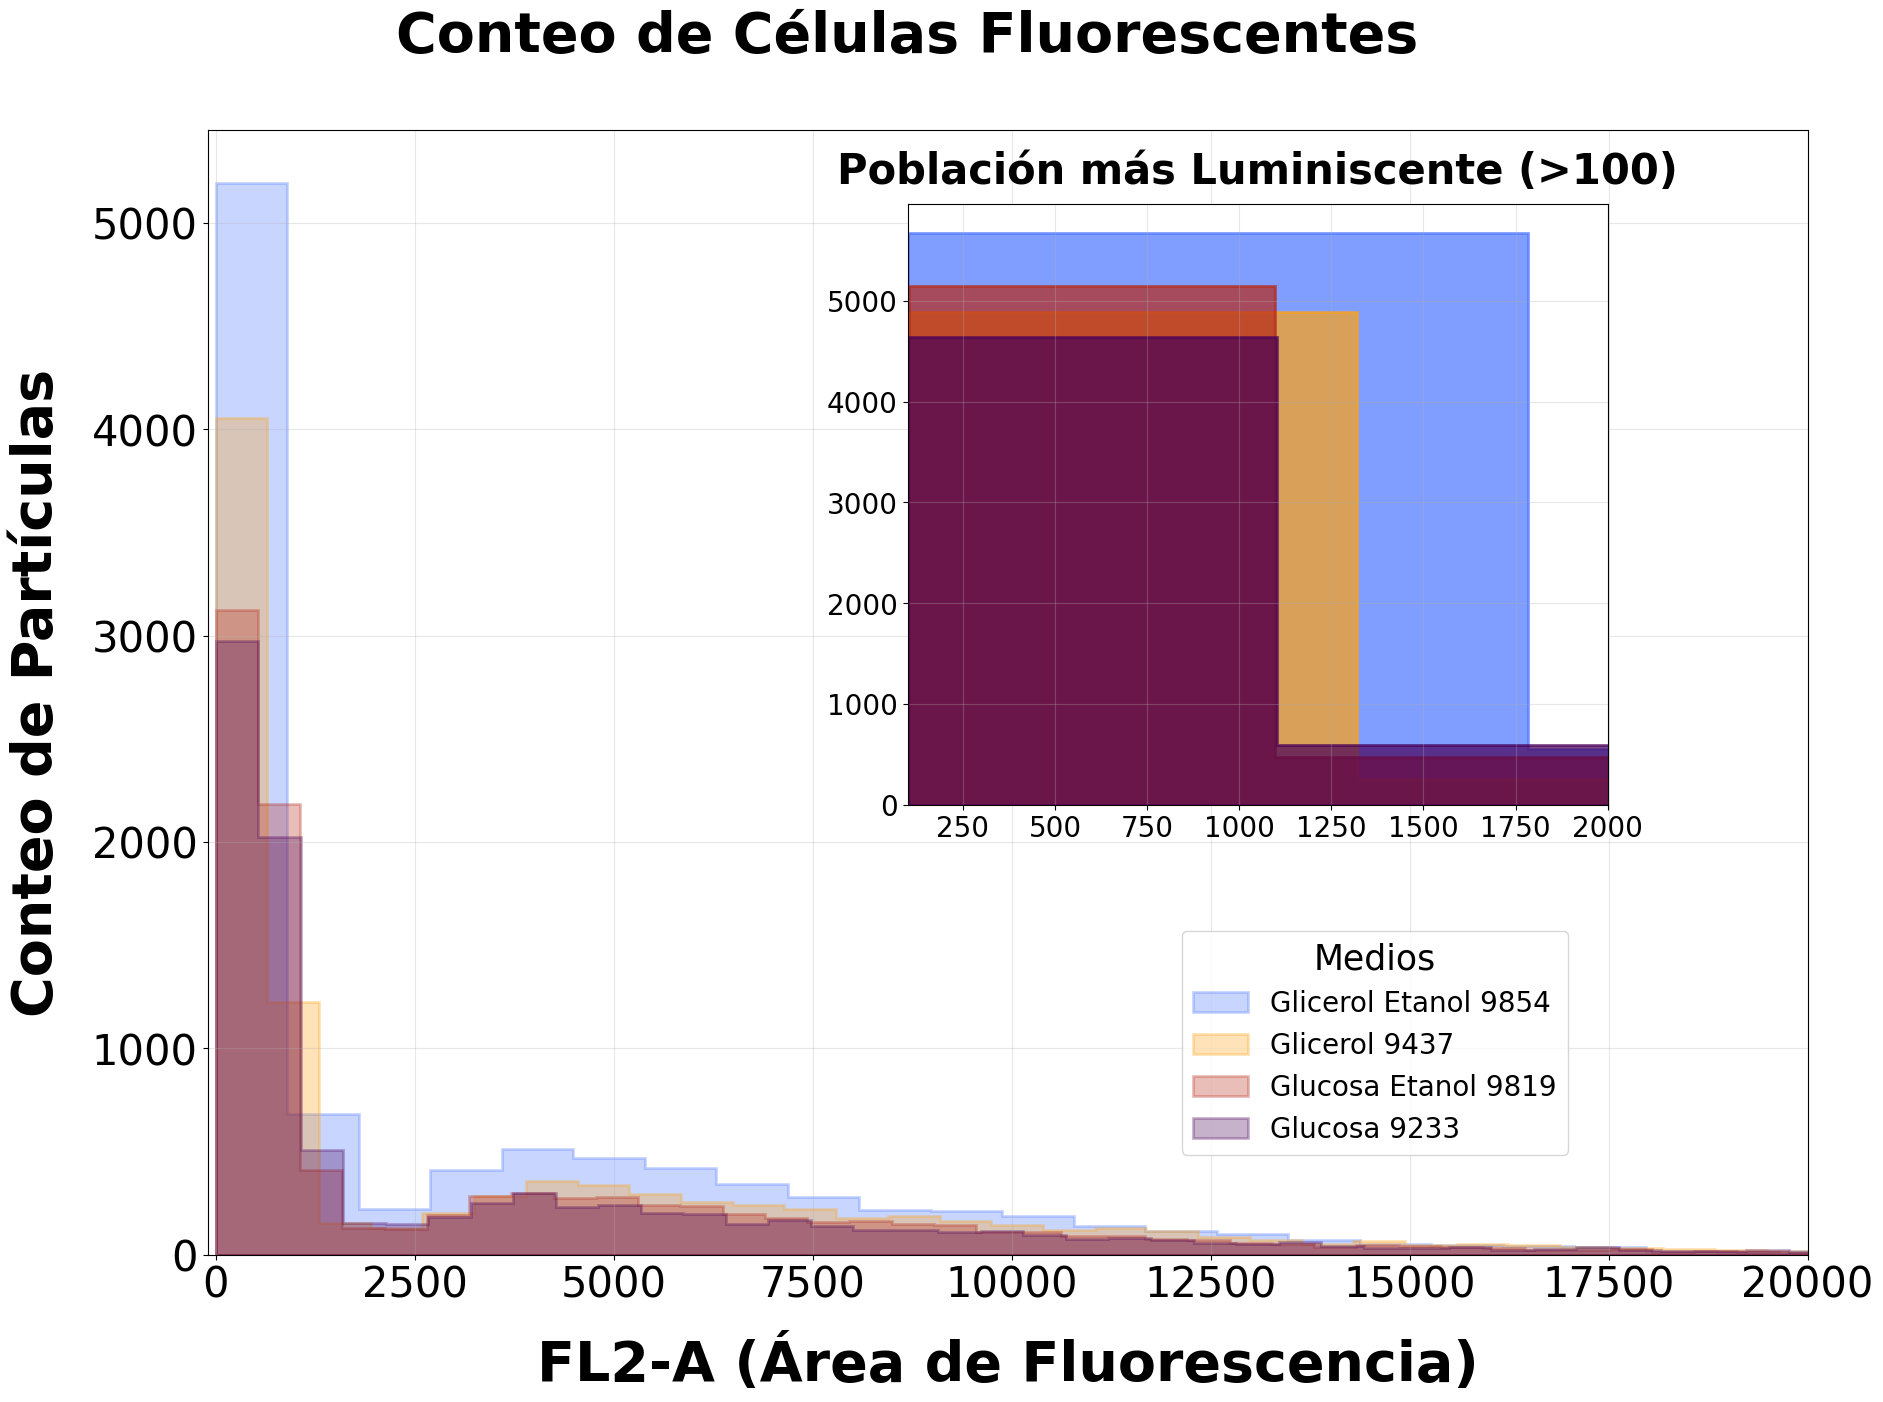

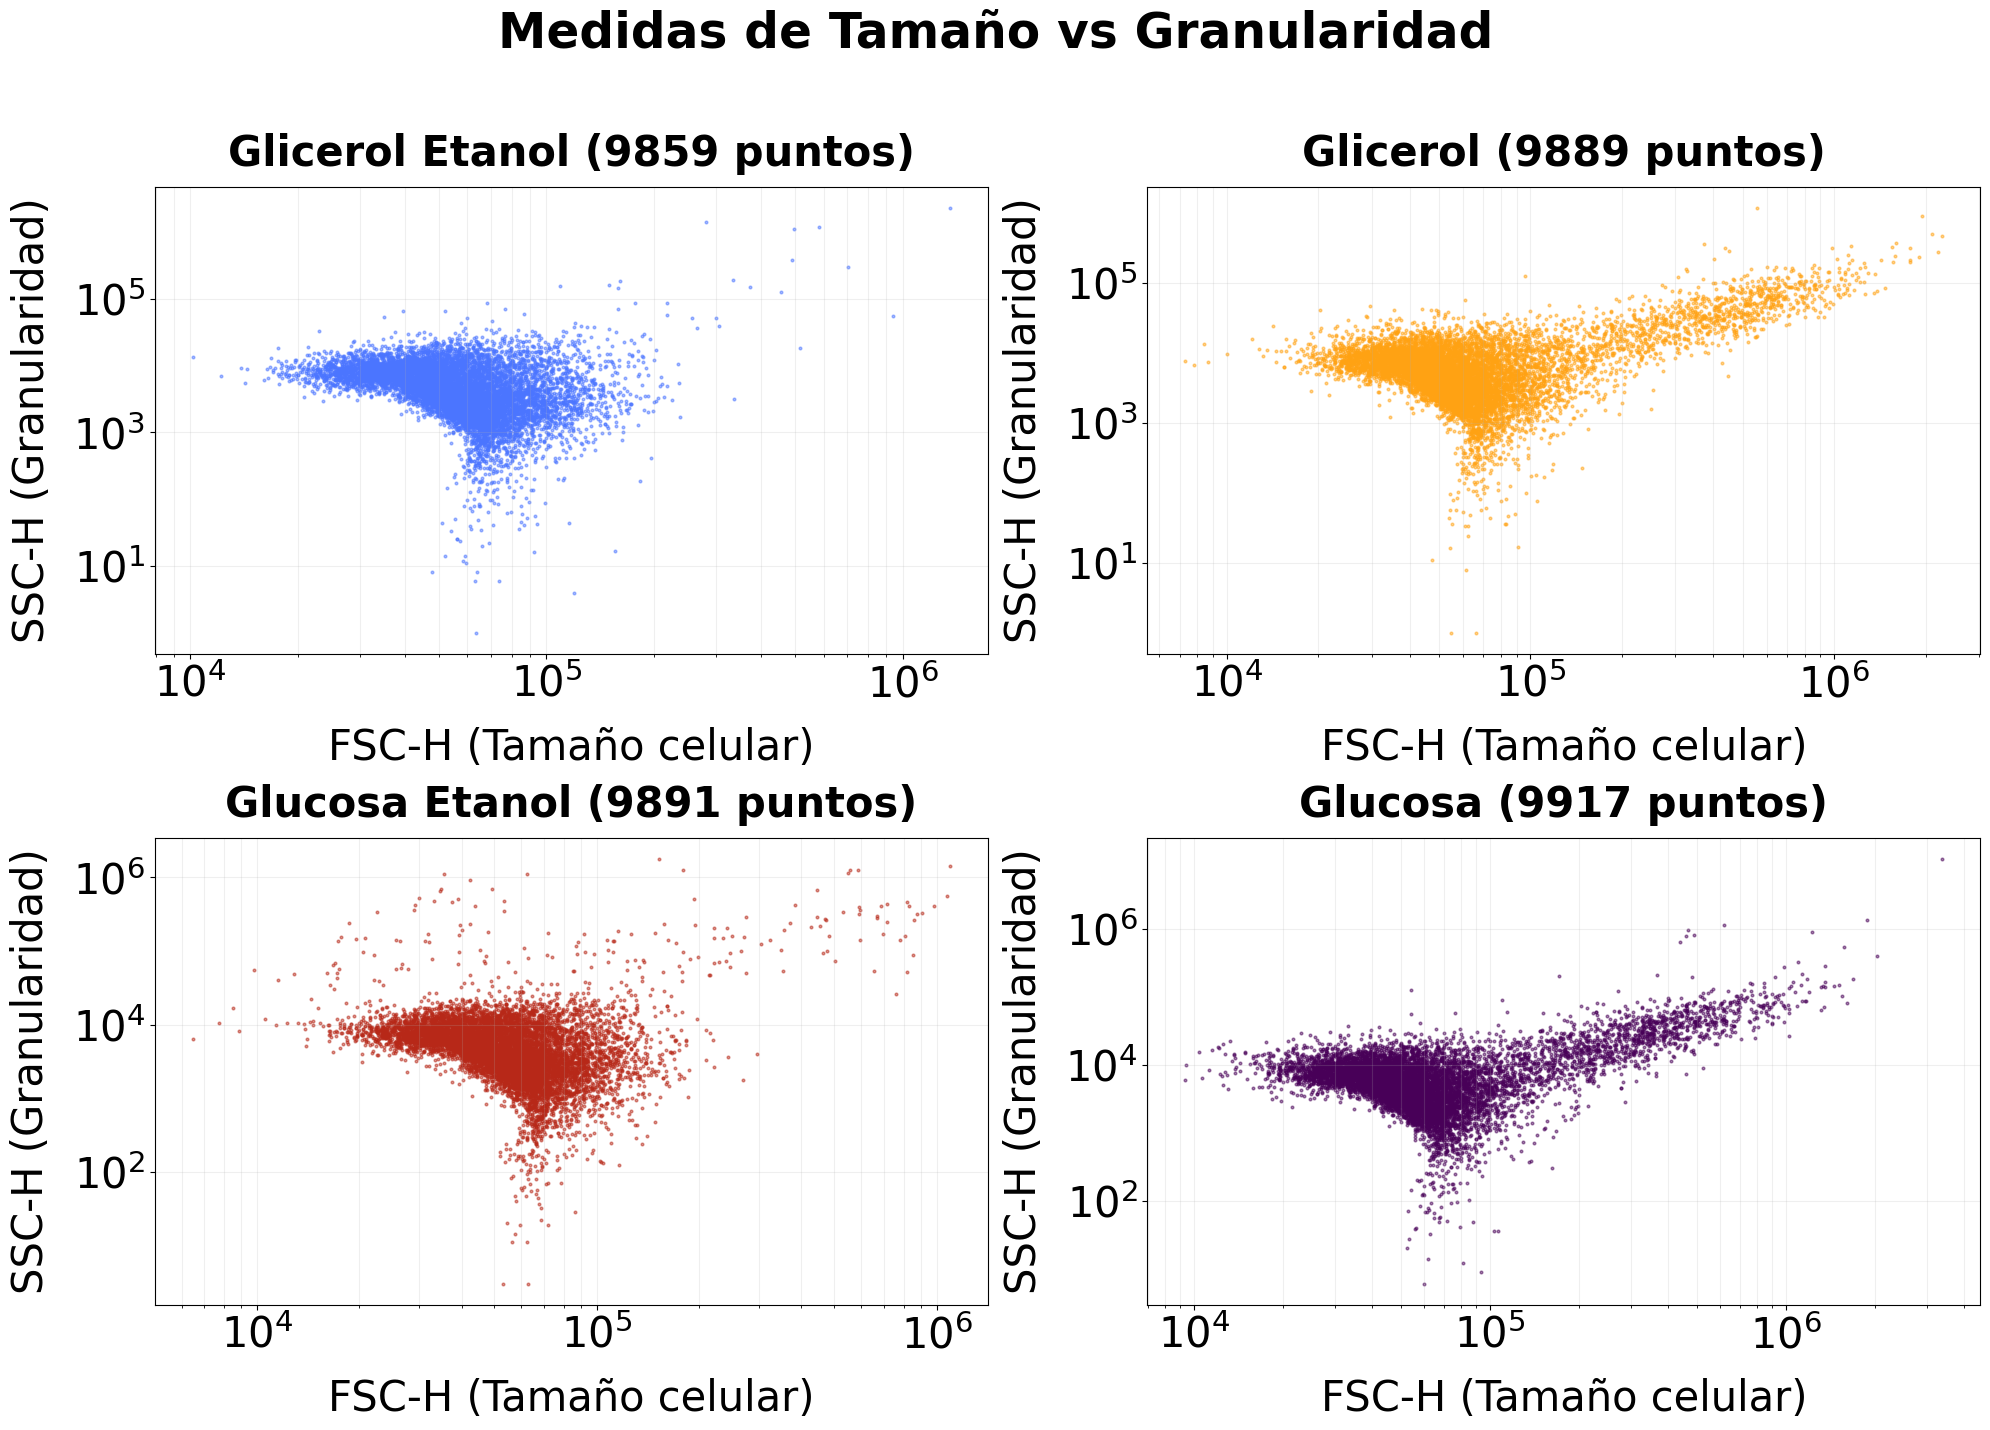

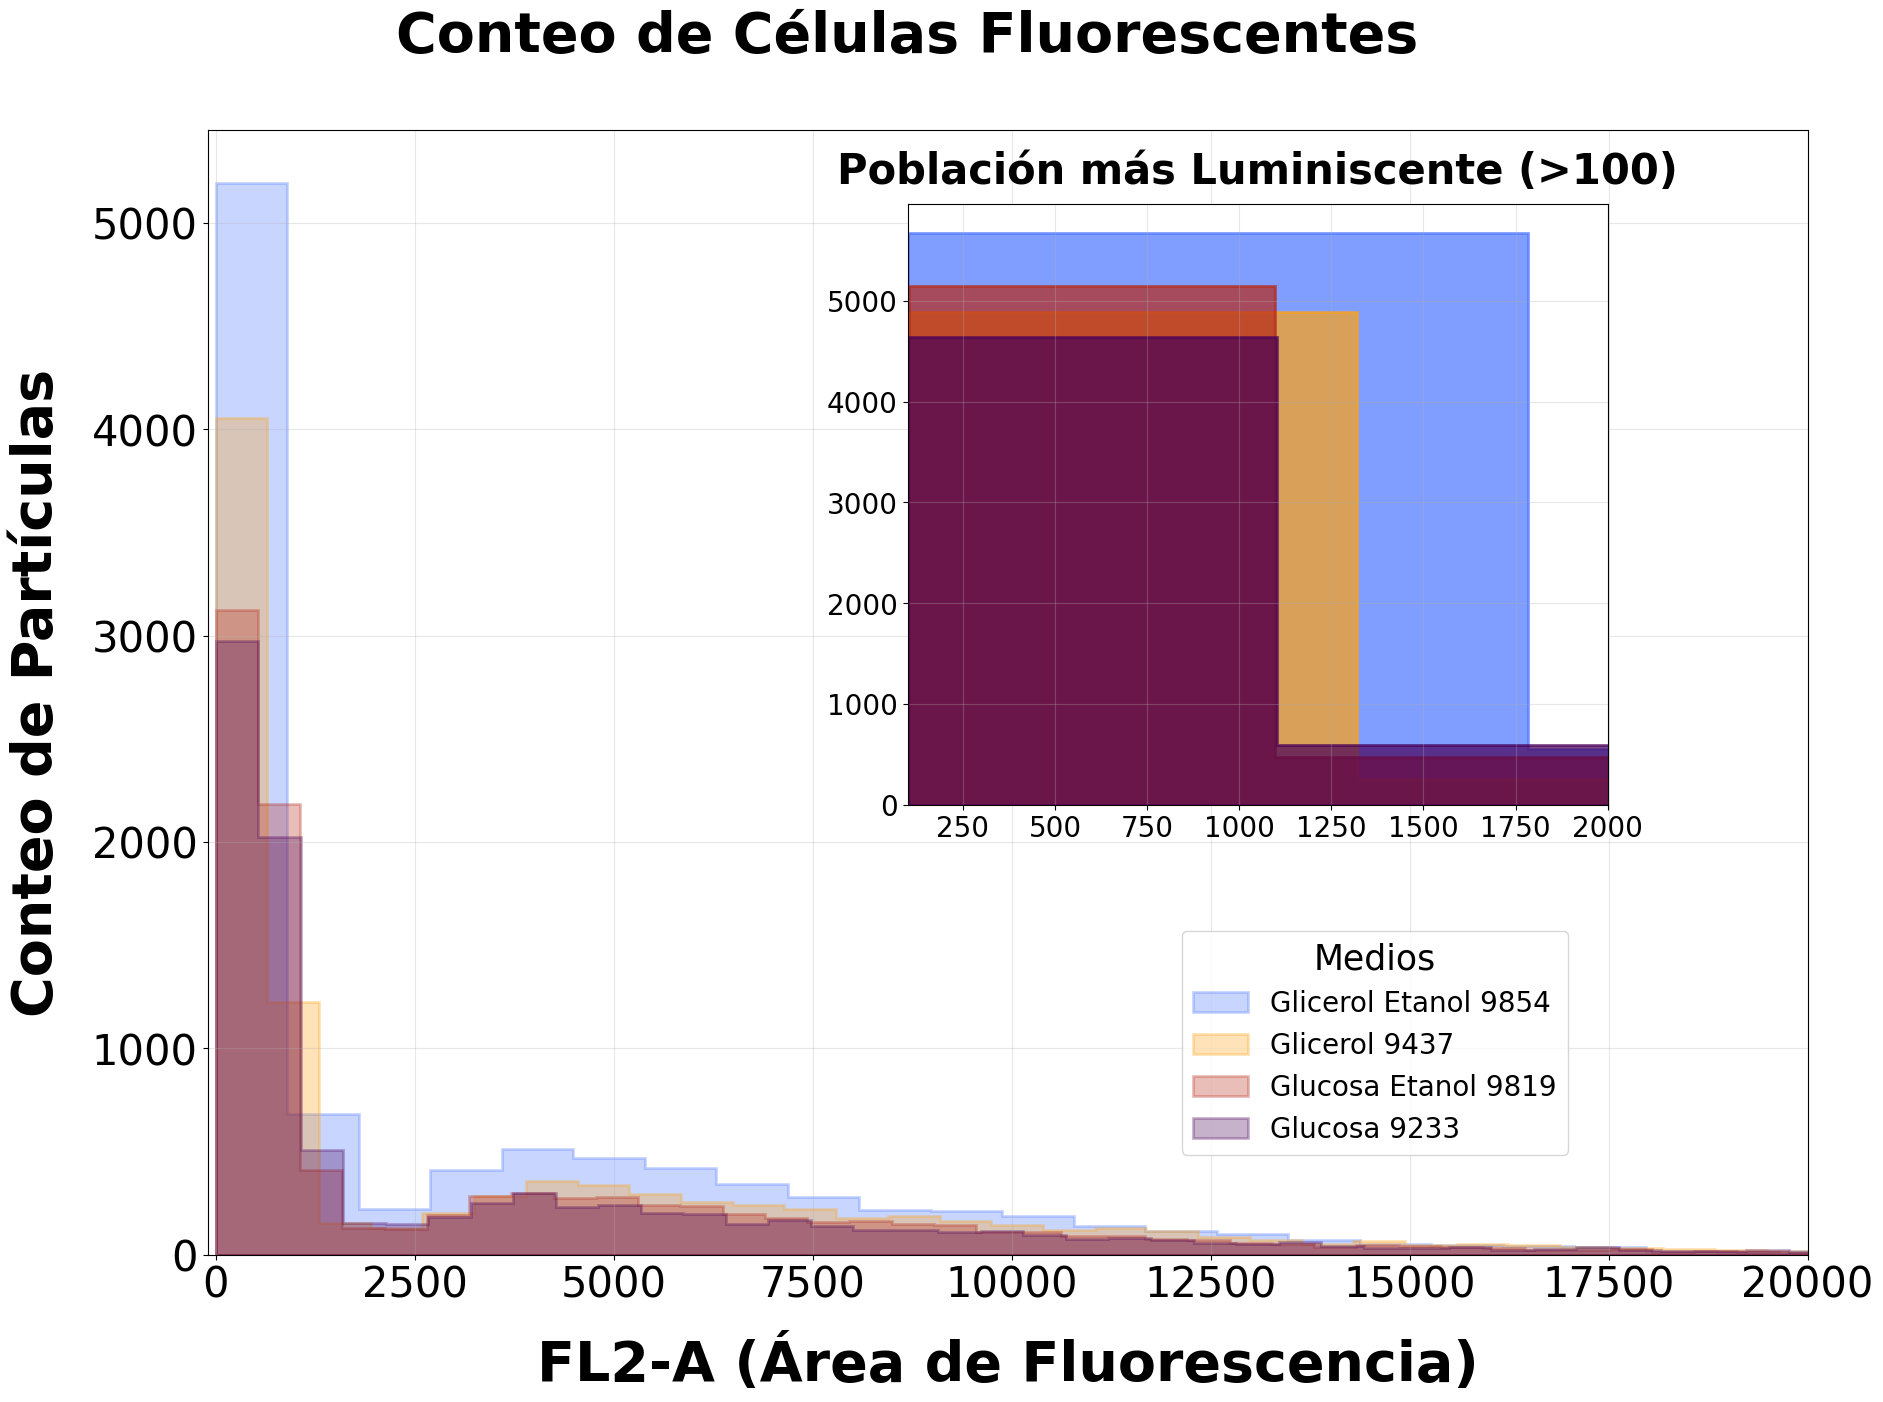

In [434]:
glicerol = cargar_datos_csv_listas('Citometro/Erol.csv')
glicerol_etanol = cargar_datos_csv_listas('Citometro/Erolol.csv')
glucosa = cargar_datos_csv_listas('Citometro/Osa.csv')
glucosa_etanol = cargar_datos_csv_listas('Citometro/Osaol.csv')


# Crear diccionario con los datos
datos_muestras = {
    
    'glicerol_etanol': (glicerol_etanol[2], glicerol_etanol[6], glicerol_etanol[1]),
    'glicerol': (glicerol[2], glicerol[6], glicerol[1]),
    'glucosa_etanol': (glucosa_etanol[2], glucosa_etanol[6], glucosa_etanol[1]),  
    'glucosa': (glucosa[2], glucosa[6], glucosa[1]),
    
}

grafica_scatter(datos_muestras, "DatosControl")
grafica_histograma(datos_muestras, "DatosControl")

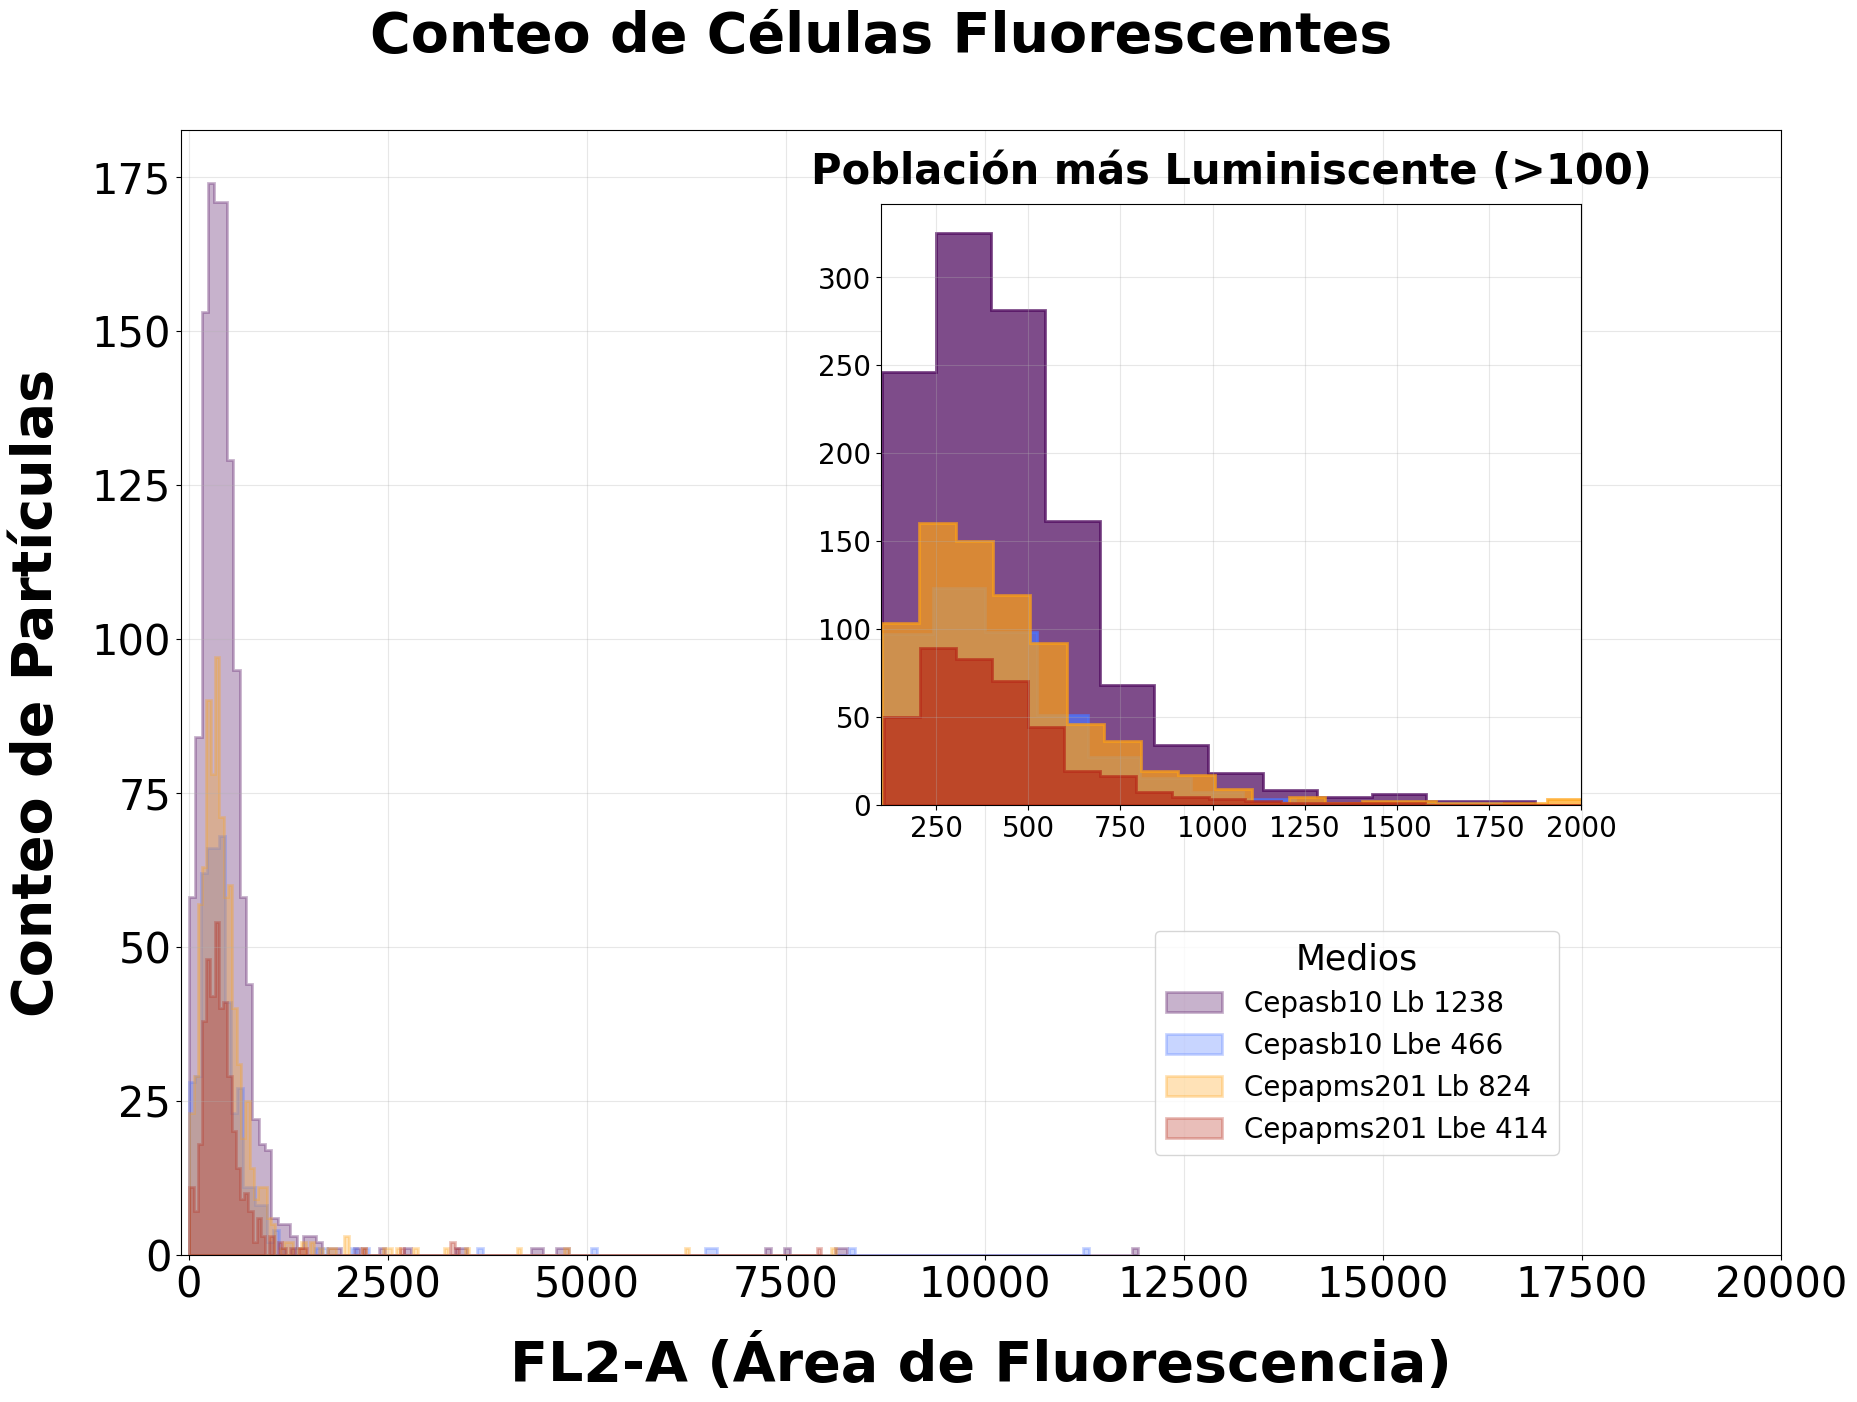

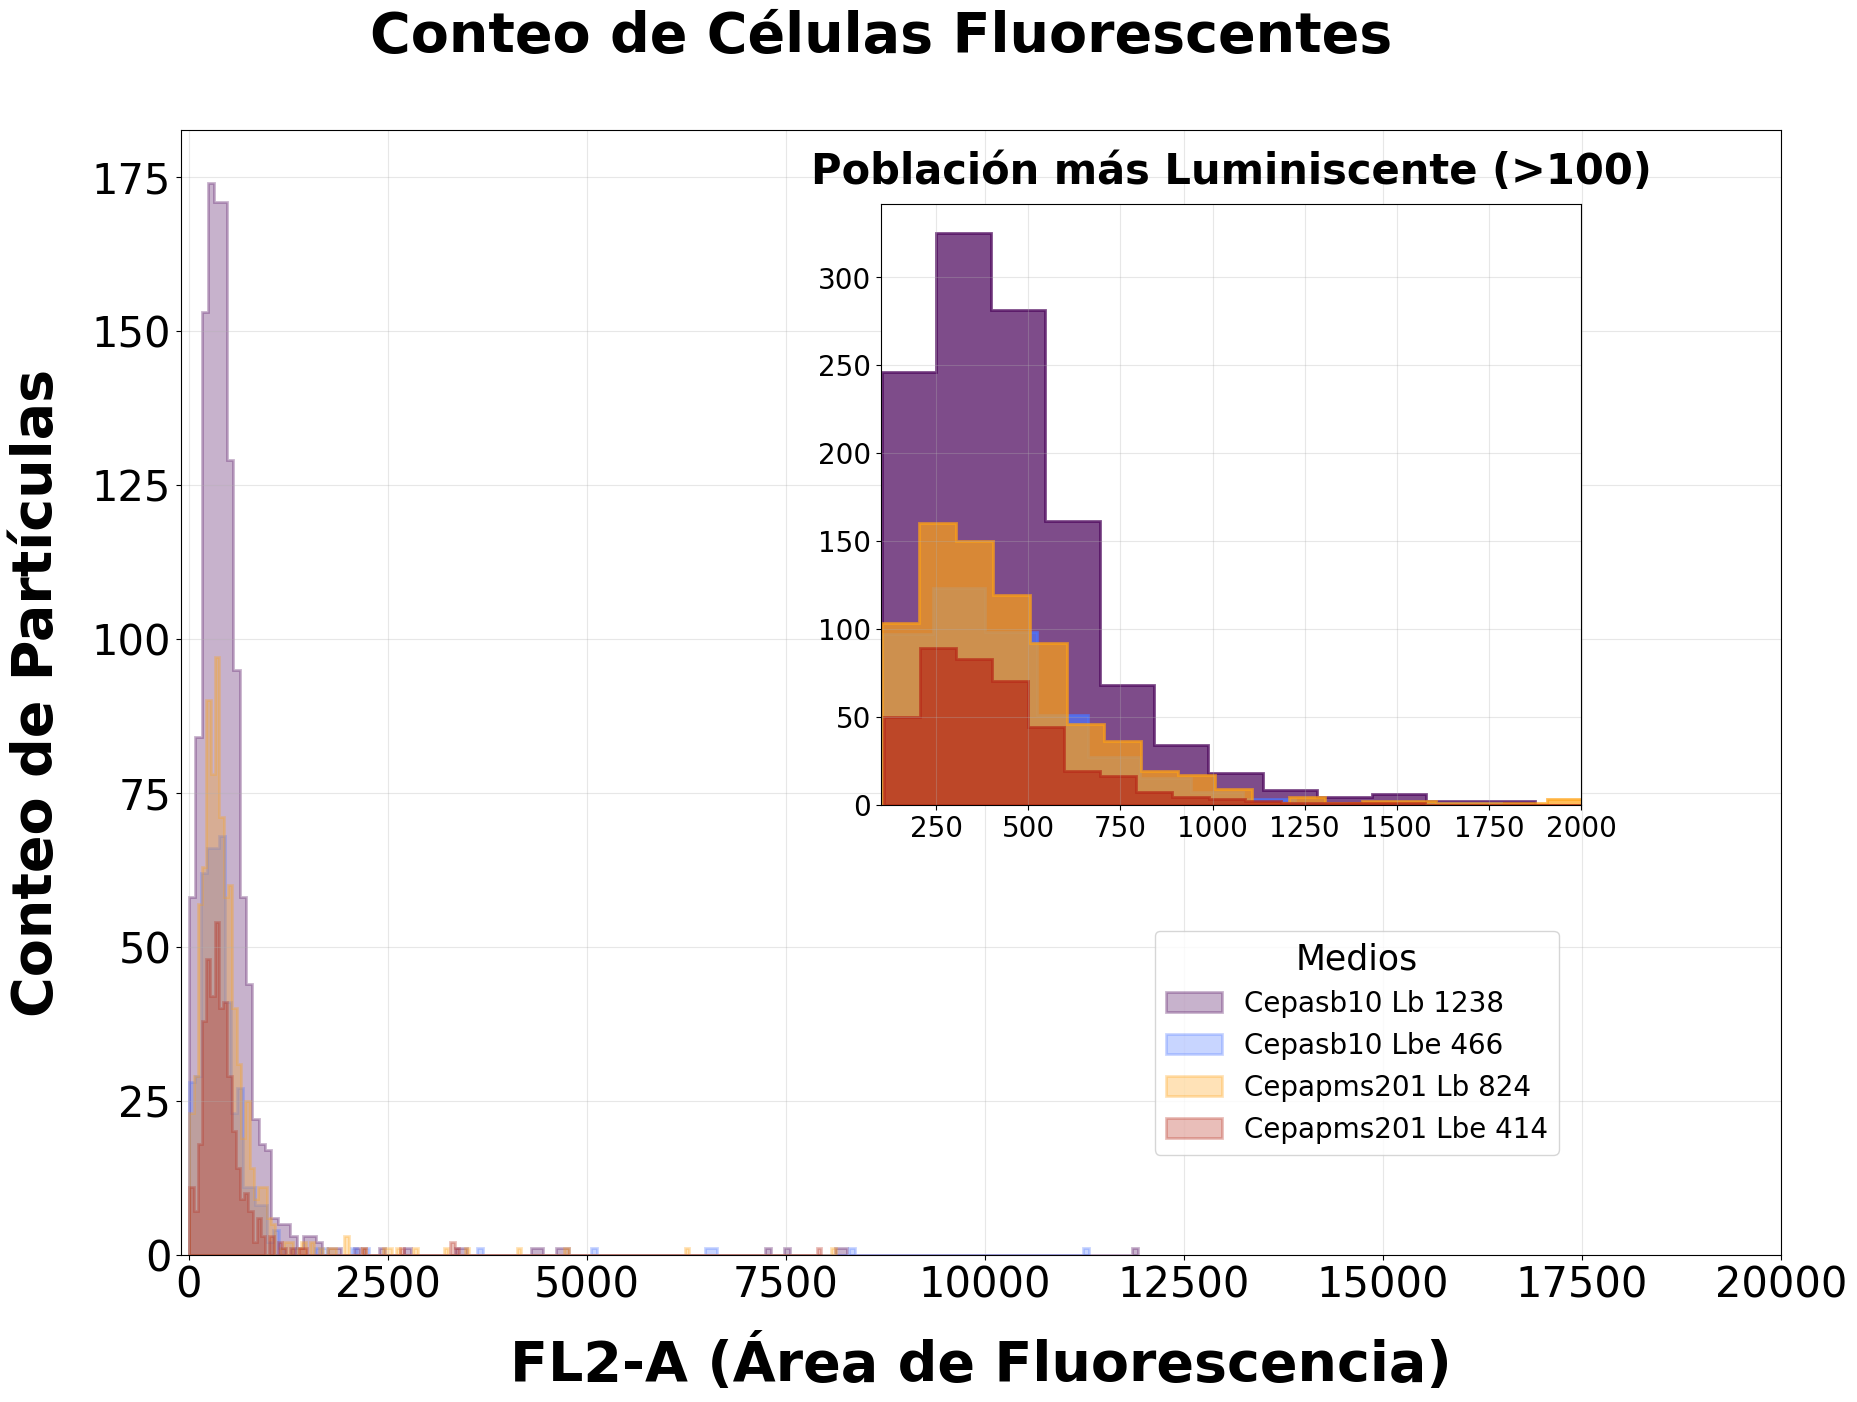

In [435]:
cepaSB10_LB_toma1 = cargar_datos_csv_listas('Citometro 2/AAA2.csv')
cepapMS201_LB_toma1 = cargar_datos_csv_listas('Citometro 2/AAA3.csv')
cepapMS201_LBE_toma1 = cargar_datos_csv_listas('Citometro 2/AAB2.csv')
cepaSB10_LBE_toma1= cargar_datos_csv_listas('Citometro 2/AAB3.csv')


# Crear diccionario con los datos
datos_muestras = {
    'cepaSB10_LB': (cepaSB10_LB_toma1[4], cepaSB10_LB_toma1[6], cepaSB10_LB_toma1[1]),
    'cepaSB10_LBE': (cepaSB10_LBE_toma1[4], cepaSB10_LBE_toma1[6], cepaSB10_LBE_toma1[1]),
    'cepapMS201_LB': (cepapMS201_LB_toma1[4], cepapMS201_LB_toma1[6], cepapMS201_LB_toma1[1]),  
    'cepapMS201_LBE': (cepapMS201_LBE_toma1[4], cepapMS201_LBE_toma1[6], cepapMS201_LBE_toma1[1]),
    
    
    
}


#grafica_scatter(datos_muestras, "DatosControl")
grafica_histograma(datos_muestras, "DatosControl")

Scatter guardado: c:\Users\Administrador\Desktop\Proyecto-Experimental\Datos\DatosControl_scatter.png


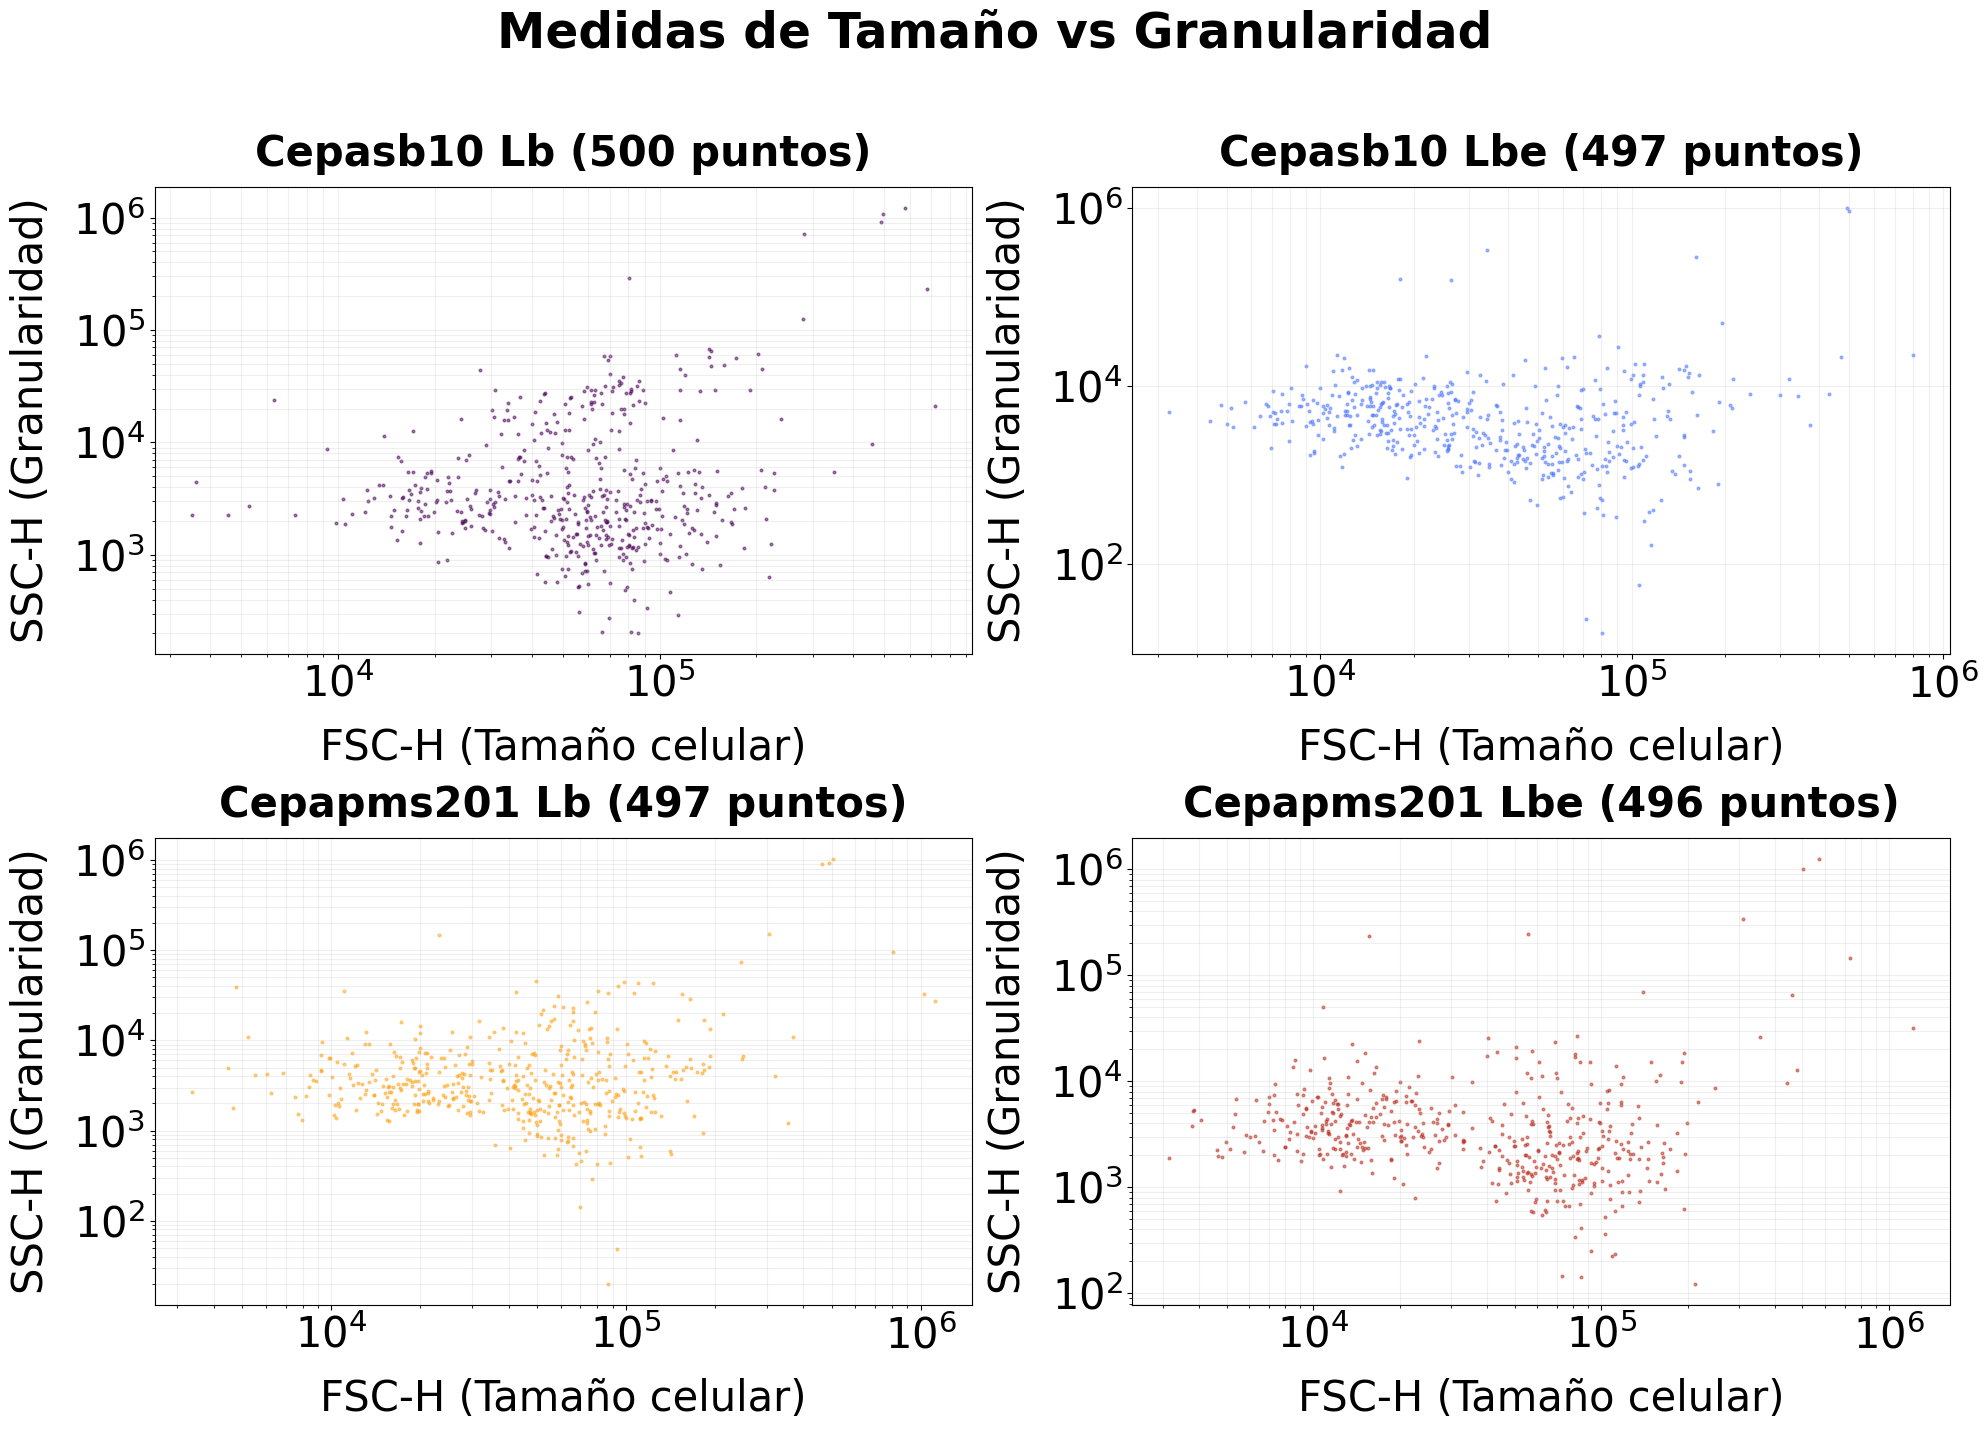

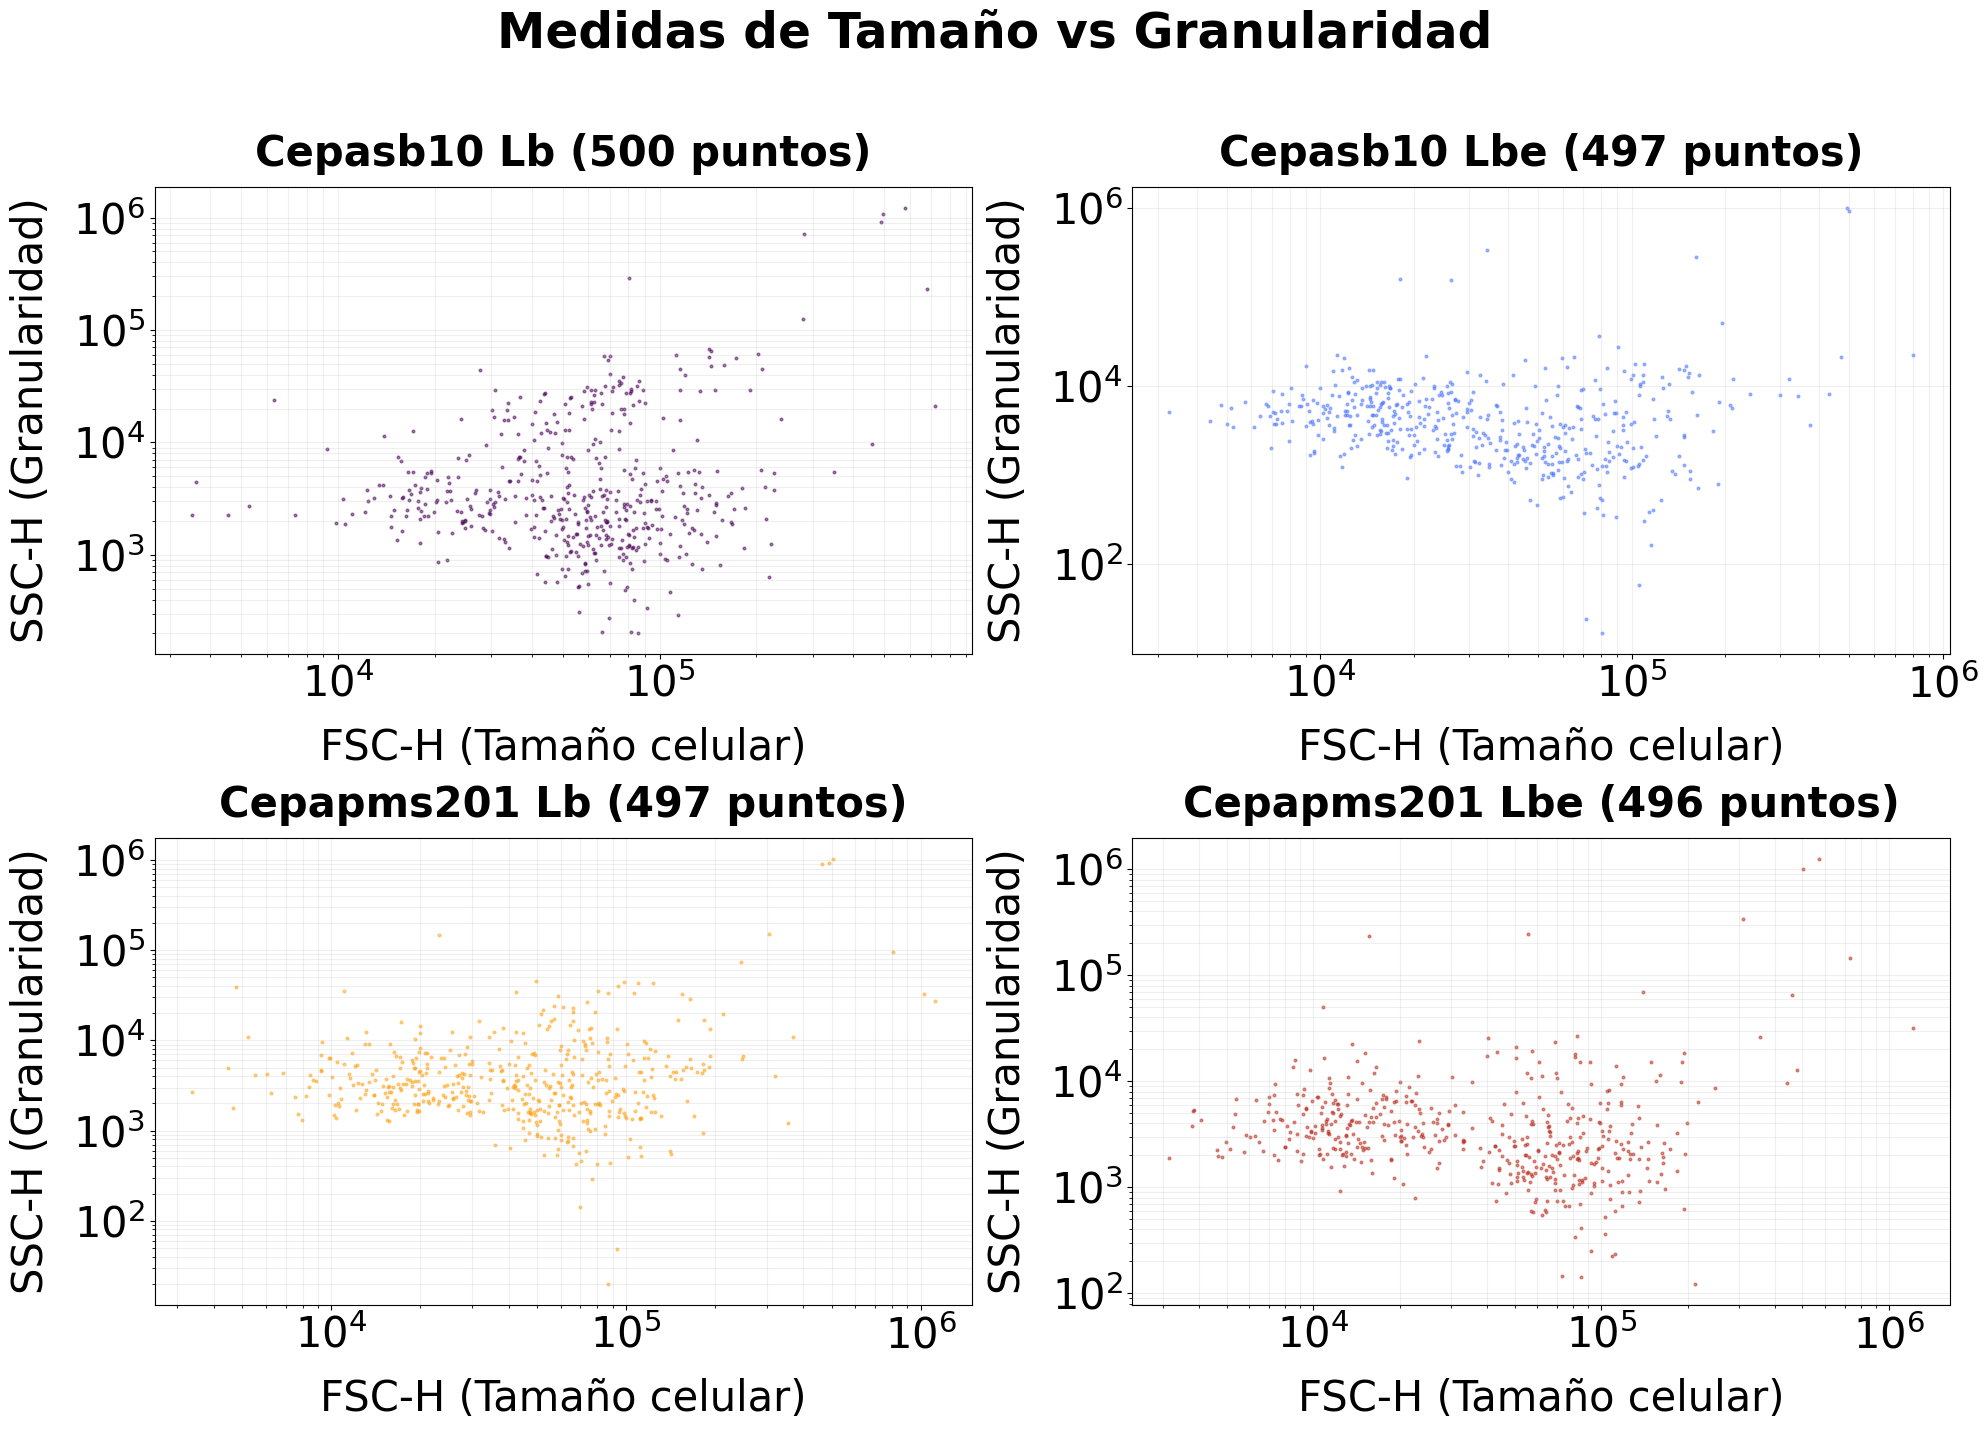

In [437]:
cepaSB10_LB_toma2 = cargar_datos_csv_listas('Citometro 2/AAC2.csv')
cepapMS201_LB_toma2 = cargar_datos_csv_listas('Citometro 2/AAC3.csv')
cepapMS201_LBE_toma2 = cargar_datos_csv_listas('Citometro 2/AAD2.csv')
cepaSB10_LBE_toma2= cargar_datos_csv_listas('Citometro 2/AAD3.csv')


# Crear diccionario con los datos
datos_muestras = {
    'cepaSB10_LB': (cepaSB10_LB_toma2[4], cepaSB10_LB_toma2[6], cepaSB10_LB_toma2[1]),
    'cepaSB10_LBE': (cepaSB10_LBE_toma2[4], cepaSB10_LBE_toma2[6], cepaSB10_LBE_toma2[1]),
    'cepapMS201_LB': (cepapMS201_LB_toma2[4], cepapMS201_LB_toma2[6], cepapMS201_LB_toma2[1]),  
    'cepapMS201_LBE': (cepapMS201_LBE_toma2[4], cepapMS201_LBE_toma2[6], cepapMS201_LBE_toma2[1]),
    
    
    
}


grafica_scatter(datos_muestras, "DatosControl")
#grafica_histograma(datos_muestras, "DatosControl")

In [ ]:
#carga_de_datos
def cargar_datos_csv_listas(ruta_archivo):
    N = [] ;     Area = [] ;    Mean = [] ;    StdDev = [];     Min = [] ;    Max = []
    
    with open(ruta_archivo, newline='') as archivo:  #
        lector = csv.reader(archivo)
        next(lector)  
        
        for fila in lector:
            N.append(int(fila[0]))
            Area.append(float(fila[1]))
            Mean.append(float(fila[2]))
            StdDev.append(float(fila[3]))
            Min.append(float(fila[4]))
            Max.append(float(fila[5]))

    return (N, Area, Mean, StdDev, Min, Max)